# 2 Solving the model numerically

### 2.1 A two-dimensional grid search

In [1]:
%load_ext autoreload
%autoreload 2

from types import SimpleNamespace
from functools import partial
import time

from scipy import optimize
import numpy as np

import matplotlib.pyplot as plt


In [2]:
from Our_Consumer import ConsumerClass

model = ConsumerClass()

opt = model.solve_grid(N=200)


s1=0.5377
s2=0.2021
s3=0.2602
w=0.4372
u=3.4016


### 2.1.2 Plot

s1=0.5377
s2=0.2021
s3=0.2602
w=0.4372
u=3.4016


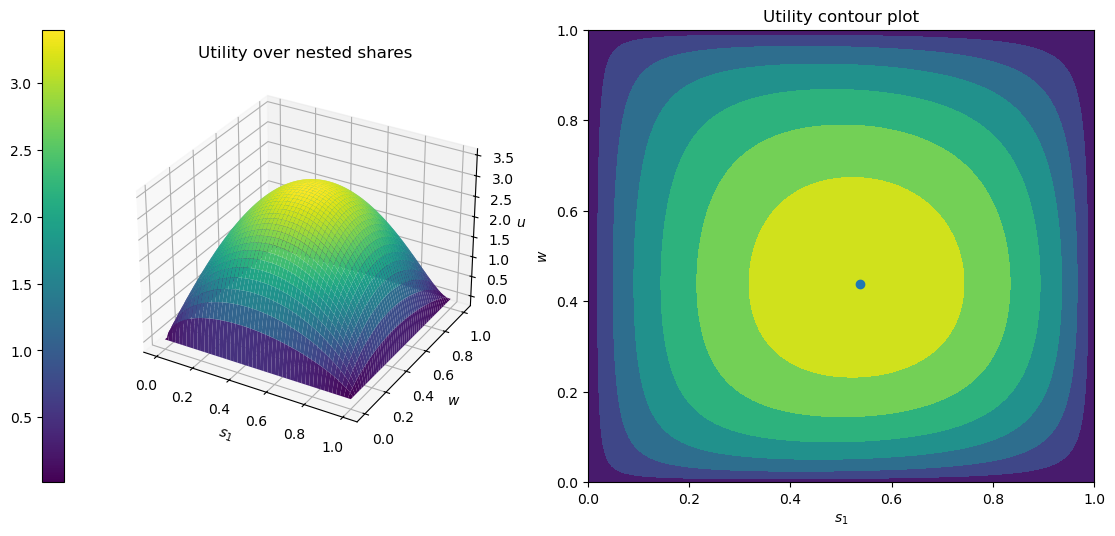

In [3]:
from Our_Consumer import ConsumerClass

model = ConsumerClass()
opt = model.solve_grid(N=200)
fig= model.plot_grid(opt)


### 2.1.3 Different values of N

s1=0.5306
s2=0.2107
s3=0.2586
w=0.4490
u=3.4007


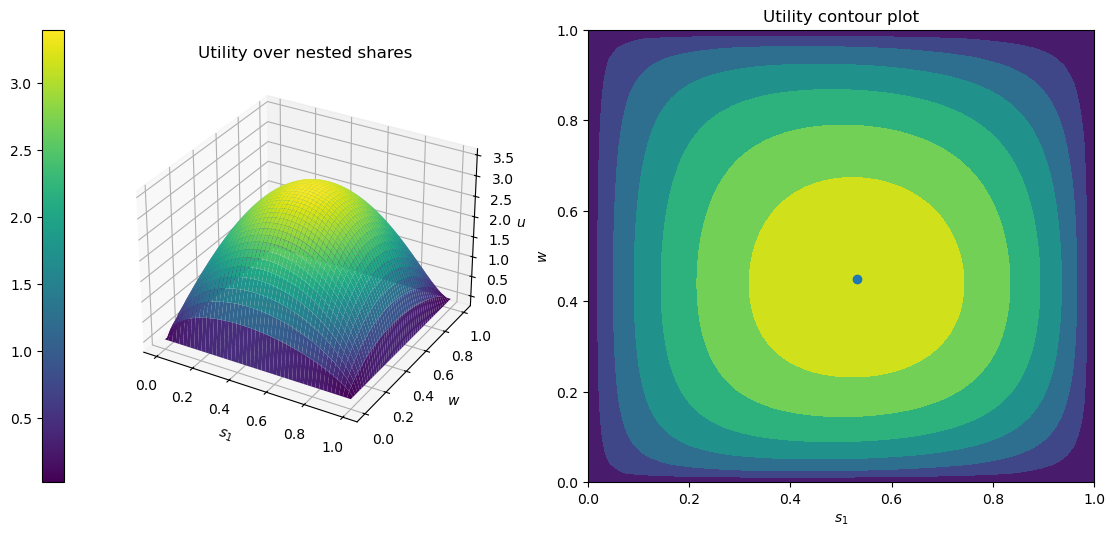

In [4]:
from Our_Consumer import ConsumerClass



opt = model.solve_grid(N=50)
fig= model.plot_grid(opt)

s1=0.5354
s2=0.2065
s3=0.2581
w=0.4444
u=3.4015


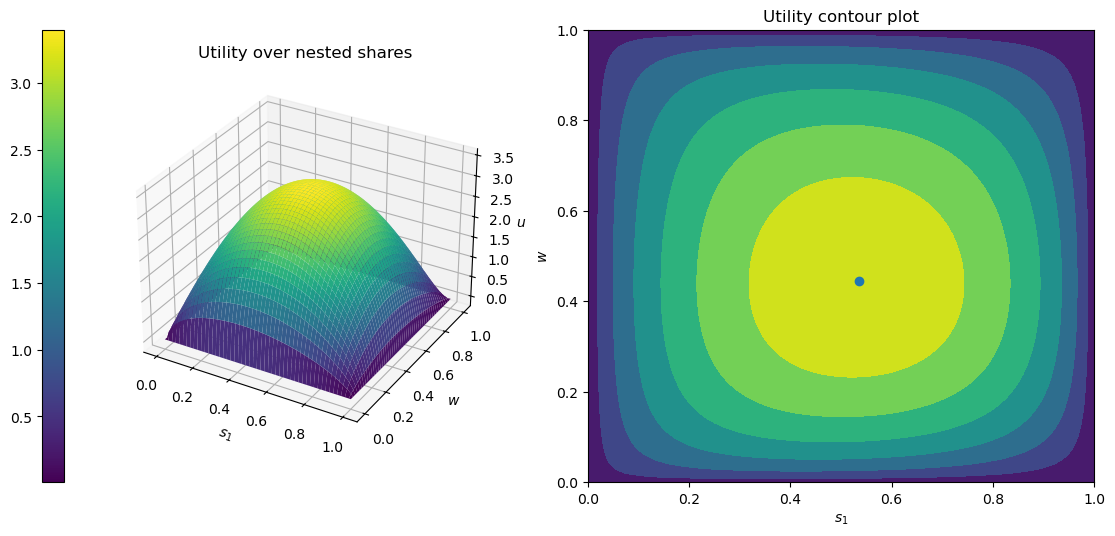

In [5]:
opt = model.solve_grid(N=100)
fig= model.plot_grid(opt)

s1=0.5351
s2=0.2040
s3=0.2609
w=0.4389
u=3.4017


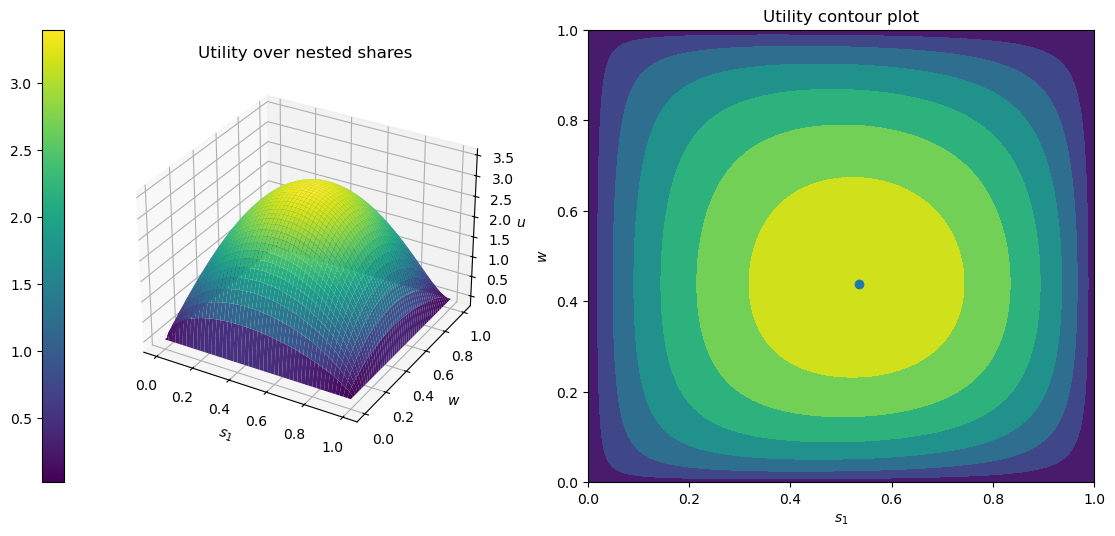

In [6]:
opt = model.solve_grid(N=500)
fig= model.plot_grid(opt)

s1=0.5355
s2=0.2041
s3=0.2604
w=0.4394
u=3.4017


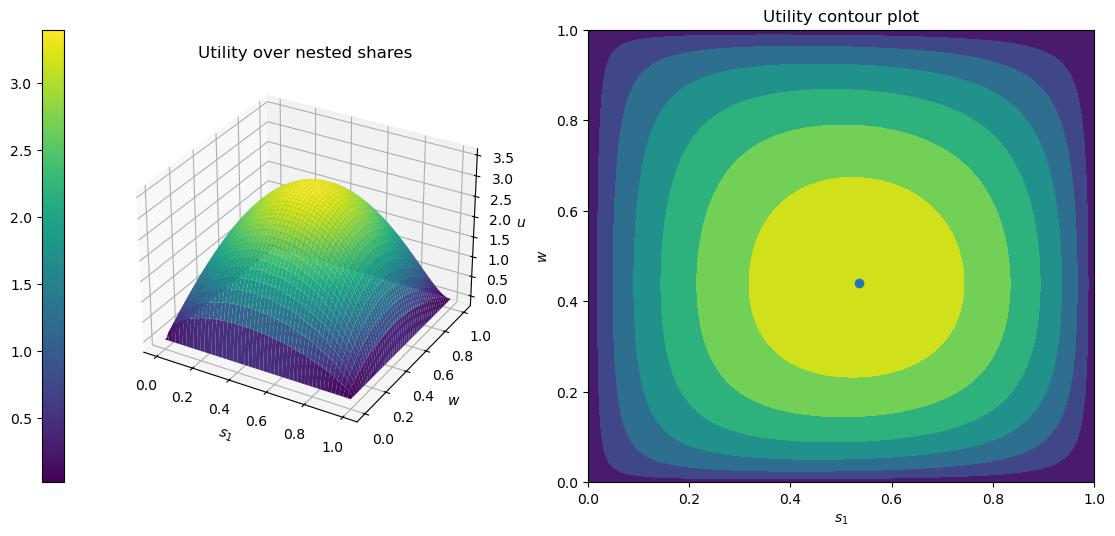

In [7]:
opt = model.solve_grid(N=1000)
fig= model.plot_grid(opt)

#### The cost of one ekstra u

A problem of size  N cost N^2 evaluations of u. 

When we add one ekstra N, the expression becomes:
(N+1)(N+1) = N^2+2N+1

If we subtract the original cost (N^2), from the cost when adding one ekstra N we get:

N^2-N^2+2N+1 = 2N+1

This means that each time N is increased by 1, it requires 2N+1 additional evaluations of u.




#### How does increasing N improve u?

An increase in N expands the grid used in the search, which increases the amount of points to choose from. This improves the chance of finding the true optimal point, which is why u grows slightly as N increase:

u = 3.4007 (N=50)
u = 3.4015 (N=100)
u = 3.4017 (N=500)
u = 3.4017 (N=1000)

However,the gain in u shrinks quickly as N increase, while the cost keeps growing, since eazch additional N cost 2N+1 extra valuations of u. Beyond N=500 the gain start to vanish. A finer grid gives more precise results, but at a certin point the cost of extra evaluations outweighs the improvement in u.

### 2.1.4 Comparing the two calibrations

#### Bus and train complements

s1=0.5377
s2=0.2021
s3=0.2602
w=0.4372
u=3.4016


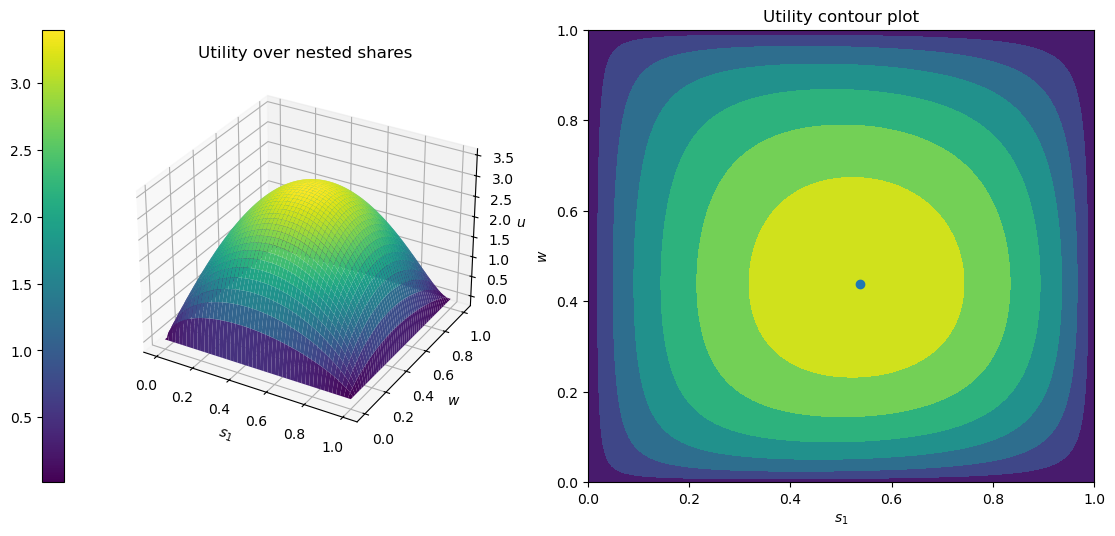

In [8]:
model_complements = ConsumerClass()

opt_complements = model_complements.solve_grid(N=200)
fig= model_complements.plot_grid(opt_complements)

When bus and train are complements the surface is a smooth rounded dome.The contour lines are formed in an oval shape around the optimum. The surface is steepest around the corners of the dome and gets flater the closer to the optimum it gets, but it doesn´t have a large flat area.

#### Bus and trains subtitutes

s1=0.5377
s2=0.3206
s3=0.1417
w=0.6935
u=3.4851


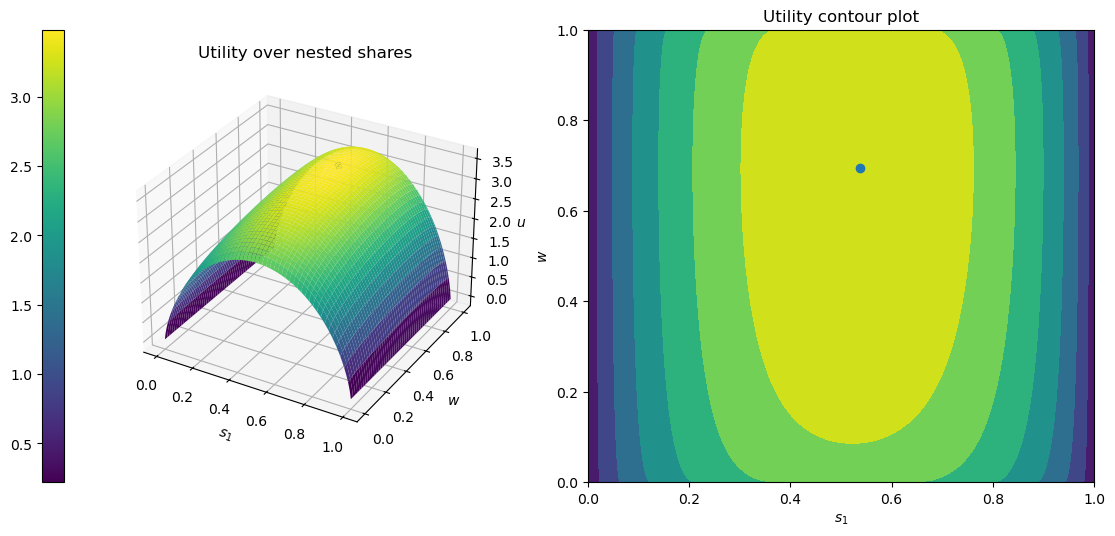

In [9]:
model_subtitutes = ConsumerClass(par={"sigma_B":3.0})

opt_subtitutes = model_subtitutes.solve_grid(N=200)
fig= model_subtitutes.plot_grid(opt_subtitutes)

The surface looks very different when bus and train are substitutes. Now it looks more like a curved tunnel. The contour lines are very steep in the two sides of the surface, but it gets a bit flatter the closer to the top it gets. Utility thereby only changes very slightly as w increases, but it falls heavily when s1 moves away from its optimal point. The surface is thereby relatively flat around the w-axis, when s1 is at its optimal point.

#### Comparison of the two calibrations

We expect the substitute calibration to be the hardest one to optimize, because it has a bigger flatter area compared to the complement calibration. Even though the substitute calibration reaches the highest utility, it has a large area where the gradient is close to zero. This makes it harder for the optimizer to find the optimal value of w because the utility only changes very slightly as w increases, thereby making it hard for the optimizer to know what direction to move.

### 2.2.1 solution L-BFGS-B

In [10]:
from Our_Consumer import ConsumerClass

consumer = ConsumerClass()
solution = consumer.solve()

print(solution)

namespace(s1=np.float64(0.5356233806953101), w=np.float64(0.43947902810370126), s2=np.float64(0.20408378532610758), s3=np.float64(0.26029283397858227), u=np.float64(3.401679875985606), path=array([[0.5       , 0.5       ],
       [0.51661738, 0.48338262],
       [0.5360763 , 0.43575106],
       [0.53560667, 0.43965199],
       [0.53562338, 0.43947903]]), res=  message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  success: True
   status: 0
      fun: -3.401679875985606
        x: [ 5.356e-01  4.395e-01]
      nit: 4
      jac: [-3.286e-06  9.637e-06]
     nfev: 18
     njev: 6
 hess_inv: <2x2 LbfgsInvHessProduct with dtype=float64>)


#### Do the two methods agree

Need to write answer

### 2.2.2 The convergenze path

s1=0.5377
s2=0.2021
s3=0.2602
w=0.4372
u=3.4016


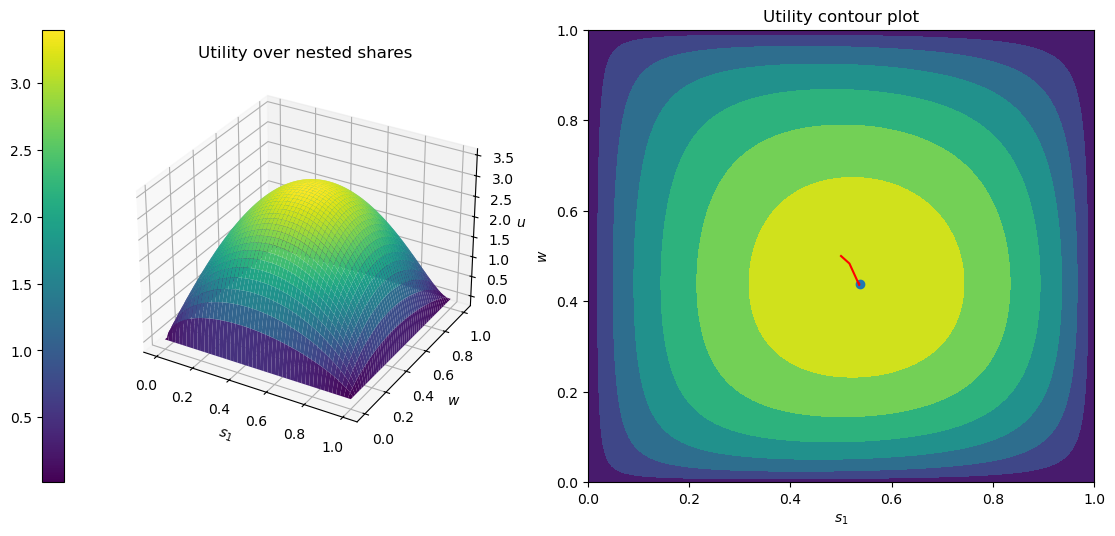

In [11]:
opt_grid = model.solve_grid(N=200)
opt_lbfgsb = model.solve()

fig = model.plot_grid(opt_grid)
ax = fig.axes[2]
ax.plot(opt_lbfgsb.path[:,0],opt_lbfgsb.path[:,1], color="red")

This method is fast if the guees is close to optimum point.

Write more

### 2.2.3 Solving with different starting points


In [12]:
opt_center =model.solve(s0=np.array([0.5,0.5]))
print(opt_center)

namespace(s1=np.float64(0.5356233806953101), w=np.float64(0.43947902810370126), s2=np.float64(0.20408378532610758), s3=np.float64(0.26029283397858227), u=np.float64(3.401679875985606), path=array([[0.5       , 0.5       ],
       [0.51661738, 0.48338262],
       [0.5360763 , 0.43575106],
       [0.53560667, 0.43965199],
       [0.53562338, 0.43947903]]), res=  message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  success: True
   status: 0
      fun: -3.401679875985606
        x: [ 5.356e-01  4.395e-01]
      nit: 4
      jac: [-3.286e-06  9.637e-06]
     nfev: 18
     njev: 6
 hess_inv: <2x2 LbfgsInvHessProduct with dtype=float64>)


In [13]:
opt_00 =model.solve(s0=np.array([0,0]))
print(opt_00)

namespace(s1=np.float64(0.5356237159937927), w=np.float64(0.4394780680750801), s2=np.float64(0.20408319215493273), s3=np.float64(0.26029309185127464), u=np.float64(3.401679875987522), path=array([[0.00000000e+00, 0.00000000e+00],
       [4.19859573e-03, 5.57044460e-04],
       [3.35493845e-01, 3.33063810e-01],
       [5.71685202e-01, 4.38541996e-01],
       [5.38013531e-01, 4.29571703e-01],
       [5.37152282e-01, 4.33367635e-01],
       [5.35641305e-01, 4.39417905e-01],
       [5.35623716e-01, 4.39478068e-01]]), res=  message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  success: True
   status: 0
      fun: -3.401679875987522
        x: [ 5.356e-01  4.395e-01]
      nit: 7
      jac: [ 2.487e-06 -5.729e-06]
     nfev: 27
     njev: 9
 hess_inv: <2x2 LbfgsInvHessProduct with dtype=float64>)


In [14]:
opt_01 =model.solve(s0=np.array([0,1]))
print(opt_01)

namespace(s1=np.float64(0.5356235717303531), w=np.float64(0.43947842830707645), s2=np.float64(0.20408342283879824), s3=np.float64(0.2602930054308486), u=np.float64(3.401679875988759), path=array([[0.        , 1.        ],
       [0.0041986 , 0.99945221],
       [0.33553192, 0.66690415],
       [0.65126381, 0.50405631],
       [0.55115988, 0.50245543],
       [0.53570894, 0.46596334],
       [0.53471893, 0.43898959],
       [0.53552242, 0.43948725],
       [0.53562321, 0.43947912],
       [0.53562357, 0.43947843]]), res=  message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  success: True
   status: 0
      fun: -3.401679875988759
        x: [ 5.356e-01  4.395e-01]
      nit: 9
      jac: [-2.220e-07  0.000e+00]
     nfev: 33
     njev: 11
 hess_inv: <2x2 LbfgsInvHessProduct with dtype=float64>)


In [15]:
opt_10 =model.solve(s0=np.array([1,0]))
print(opt_10)

namespace(s1=np.float64(0.9999906600612825), w=np.float64(0.0), s2=np.float64(0.0), s3=np.float64(9.339938717545238e-06), u=np.float64(6.177356919346663e-11), path=array([[1.        , 0.        ],
       [0.99999066, 0.        ]]), res=  message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  success: True
   status: 0
      fun: -6.177356919346663e-11
        x: [ 1.000e+00  0.000e+00]
      nit: 1
      jac: [-5.842e-14  0.000e+00]
     nfev: 21
     njev: 7
 hess_inv: <2x2 LbfgsInvHessProduct with dtype=float64>)


In [16]:
opt_11 =model.solve(s0=np.array([1,1]))
print(opt_11)

namespace(s1=np.float64(0.9999906600608381), w=np.float64(1.0), s2=np.float64(9.339939161856492e-06), s3=np.float64(0.0), u=np.float64(6.17735691935048e-11), path=array([[1.        , 1.        ],
       [0.99999066, 1.        ]]), res=  message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  success: True
   status: 0
      fun: -6.17735691935048e-11
        x: [ 1.000e+00  1.000e+00]
      nit: 1
      jac: [-5.842e-14 -0.000e+00]
     nfev: 21
     njev: 7
 hess_inv: <2x2 LbfgsInvHessProduct with dtype=float64>)


In [17]:
opt_0307 =model.solve(s0=np.array([0.3,0.7]))
print(opt_0307)

namespace(s1=np.float64(0.5356236023949758), w=np.float64(0.4394784631130846), s2=np.float64(0.20408342552544675), s3=np.float64(0.2602929720795775), u=np.float64(3.4016798759887488), path=array([[0.3       , 0.7       ],
       [0.40797125, 0.59202875],
       [0.56329413, 0.35971645],
       [0.53103357, 0.45473963],
       [0.53537144, 0.44080509],
       [0.53562967, 0.4394588 ],
       [0.5356236 , 0.43947846]]), res=  message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  success: True
   status: 0
      fun: -3.4016798759887488
        x: [ 5.356e-01  4.395e-01]
      nit: 6
      jac: [ 3.997e-07  3.997e-07]
     nfev: 24
     njev: 8
 hess_inv: <2x2 LbfgsInvHessProduct with dtype=float64>)


#### Results and number of iterations

Need to write answer